<a href="https://colab.research.google.com/github/Ismot10/Disaster-Management-and-Early-Warning-System-App/blob/main/Storm_AI_(fused_event_classification%2C_TFLite_for_Flutter).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# CELL 1 — Install & Import

!pip install pandas numpy matplotlib scikit-learn tensorflow --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GRU, Conv1D, MaxPooling1D
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
# CELL 2 — Upload dataset (or use your file)

from google.colab import files
uploaded = files.upload()

Saving storm_prediction_dataset.csv to storm_prediction_dataset (1).csv


In [ ]:
# CELL 3 — Load & Inspect

df = pd.read_csv("storm_prediction_dataset.csv")

df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
df = df.dropna(subset=["timestamp"]).sort_values("timestamp")

print(df.shape)
df.head()

(11800, 9)


,timestamp,distance_cm,rain_percent,water_percent,wind_speed_mps,flood_risk,storm_risk,fused_event,fused_risk
0,2026-02-01 00:00:00,94.1,16,15,1.67,Low,Normal,Normal,Normal
1,2026-02-01 00:00:03,93.9,21,15,1.18,Low,Normal,Normal,Normal
2,2026-02-01 00:00:06,94.6,19,18,1.39,Low,Normal,Normal,Normal
3,2026-02-01 00:00:09,95.0,18,11,0.00,Low,Normal,Normal,Normal
4,2026-02-01 00:00:12,91.6,10,10,1.09,Low,Normal,Normal,Normal


In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=df)

https://docs.google.com/spreadsheets/d/1sDw3Teiaobglj5M7odRm66RQbmjL6pW_uIHOW0gOPYI/edit#gid=0


In [ ]:
# CELL 4 — Clean (remove empty/invalid rows)

# Remove rows where everything is zero (optional but recommended)
sensor_cols = ["distance_cm", "rain_percent", "water_percent", "wind_speed_mps"]

df = df.dropna(subset=sensor_cols + ["fused_event"])
df = df[(df[sensor_cols].abs().sum(axis=1) > 0) | (df["fused_event"] != "Normal")]

print("After cleaning:", df.shape)
df["fused_event"].value_counts()

After cleaning: (11800, 9)


,count
fused_event,
Normal,5248
Cyclone+Flood,2214
StormOnly,2048
FloodLikely,1435
CycloneOnly,855


In [ ]:
# CELL 5 — Select Features + Label

features = ["wind_speed_mps", "rain_percent", "water_percent", "distance_cm"]
X_raw = df[features].astype(float)

y_raw = df["fused_event"].astype(str)

In [ ]:
# CELL 6 — Encode Label (classes)

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_raw)

class_names = list(label_encoder.classes_)
num_classes = len(class_names)

print("Classes:", class_names)
print("num_classes:", num_classes)

Classes: ['Cyclone+Flood', 'CycloneOnly', 'FloodLikely', 'Normal', 'StormOnly']
num_classes: 5


In [ ]:
# CELL 7 — Normalize Features

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_raw)

In [ ]:
# CELL 8 — Create Sequences (like your flood LSTM)

SEQUENCE_LENGTH = 10

X_seq = []
y_seq = []

for i in range(SEQUENCE_LENGTH, len(X_scaled)):
    X_seq.append(X_scaled[i-SEQUENCE_LENGTH:i])
    y_seq.append(y_encoded[i])   # event at time i

X_seq = np.array(X_seq, dtype=np.float32)
y_seq = np.array(y_seq, dtype=np.int32)

print("X_seq:", X_seq.shape)  # (samples, 10, 4)
print("y_seq:", y_seq.shape)

X_seq: (11790, 10, 4)
y_seq: (11790,)


In [ ]:
# CELL 9 — Train/Test Split (time-ordered, no shuffle)

X_train, X_test, y_train, y_test = train_test_split(
    X_seq, y_seq, test_size=0.2, shuffle=False
)

y_train_oh = tf.keras.utils.to_categorical(y_train, num_classes=num_classes)
y_test_oh  = tf.keras.utils.to_categorical(y_test,  num_classes=num_classes)

In [ ]:
# ✅ CELL 10 — Build Model (CNN1D + GRU, TFLite-friendly)

model = Sequential([
    Conv1D(32, kernel_size=3, activation="relu", input_shape=(SEQUENCE_LENGTH, len(features))),
    MaxPooling1D(pool_size=2),
    Dropout(0.2),

    GRU(32, unroll=True, activation="tanh", recurrent_activation="sigmoid"),
    Dense(32, activation="relu"),
    Dropout(0.2),

    Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_1 (Conv1D)               │ (None, 8, 32)          │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 4, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 32)             │         6,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,973 (31.14 KB)

 Trainable params: 7,973 (31.14 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ✅ CELL 11 — Train

early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train_oh,
    validation_data=(X_test, y_test_oh),
    epochs=40,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/40
295/295 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.6521 - loss: 0.9451 - val_accuracy: 0.4075 - val_loss: 1.6933
Epoch 2/40
295/295 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7942 - loss: 0.5171 - val_accuracy: 0.6179 - val_loss: 1.1062
Epoch 3/40
295/295 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8089 - loss: 0.4660 - val_accuracy: 0.7146 - val_loss: 0.8219
Epoch 4/40
295/295 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8232 - loss: 0.4288 - val_accuracy: 0.5874 - val_loss: 0.7468
Epoch 5/40
295/295 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8312 - loss: 0.4236 - val_accuracy: 0.5852 - val_loss: 0.7769
Epoch 6/40
295/295 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8378 - loss: 0.3966 - val_accuracy: 0.7154 - val_loss: 0.6458
Epoch 7/40
295/295 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8503 - loss: 0.3794 - val_accuracy: 0.8550 - val_loss: 0.5441
Epoch 8/40
295/295 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8491 - loss: 0.3709 - val_accuracy: 0.

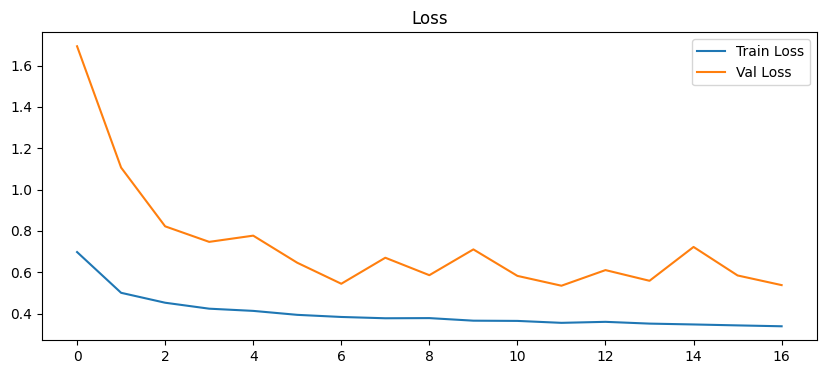

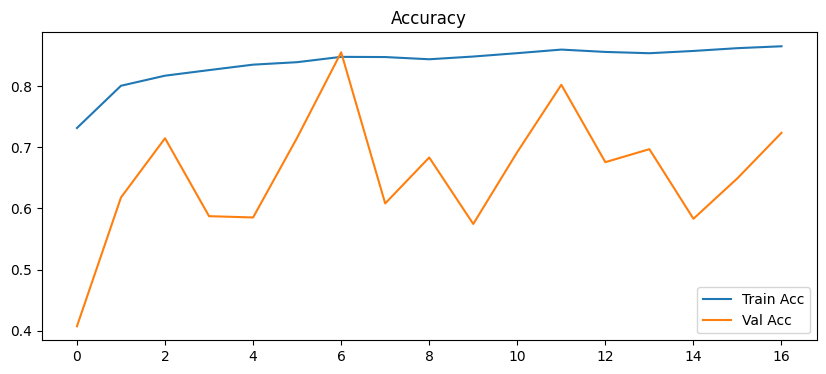

In [ ]:
# ✅ CELL 12 — Plot Loss/Accuracy

plt.figure(figsize=(10,4))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.legend(); plt.title("Loss"); plt.show()

plt.figure(figsize=(10,4))
plt.plot(history.history["accuracy"], label="Train Acc")
plt.plot(history.history["val_accuracy"], label="Val Acc")
plt.legend(); plt.title("Accuracy"); plt.show()

74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Test Accuracy: 0.8019508057675997


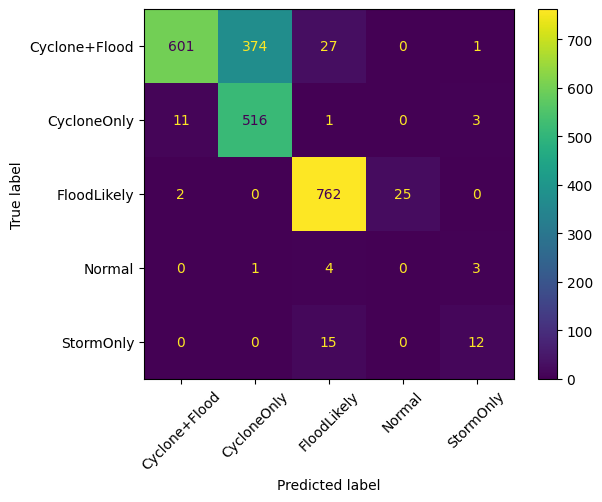

In [ ]:
# ✅ CELL 13 — Evaluate + Confusion Matrix (optional)

pred = model.predict(X_test)
pred_cls = np.argmax(pred, axis=1)
true_cls = np.argmax(y_test_oh, axis=1)

acc = (pred_cls == true_cls).mean()
print("Test Accuracy:", acc)

# Optional confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(true_cls, pred_cls)
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
disp.plot(xticks_rotation=45)
plt.show()

In [ ]:
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score, accuracy_score
import numpy as np

# predicted class ids
y_pred = np.argmax(model.predict(X_test), axis=1)

# true class ids
# y_test should already be integer encoded
# if one-hot encoded, use: y_true = np.argmax(y_test, axis=1)
y_true = y_test

acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='weighted')
rec = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1-Score:", f1)

print(classification_report(y_true, y_pred))

74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Accuracy: 0.8019508057675997
Precision: 0.8691660538799231
Recall: 0.8019508057675997
F1-Score: 0.8047069829709717
              precision    recall  f1-score   support

           0       0.98      0.60      0.74      1003
           1       0.58      0.97      0.73       531
           2       0.94      0.97      0.95       789
           3       0.00      0.00      0.00         8
           4       0.63      0.44      0.52        27

    accuracy                           0.80      2358
   macro avg       0.63      0.60      0.59      2358
weighted avg       0.87      0.80      0.80      2358



In [ ]:
# CELL 14 — Save Model + Export Scaler + Labels (important for app)

model.save("storm_fusion_event_model.keras")

# Save scaler parameters + feature order + label list for Flutter
export = {
    "features": features,
    "scaler_min": scaler.min_.tolist(),
    "scaler_scale": scaler.scale_.tolist(),
    "class_names": class_names,
    "sequence_length": SEQUENCE_LENGTH
}

import json
with open("storm_model_meta.json", "w") as f:
    json.dump(export, f, indent=2)

print("✅ Saved: storm_fusion_event_model.keras + storm_model_meta.json")

✅ Saved: storm_fusion_event_model.keras + storm_model_meta.json


In [ ]:
# CELL 15 — Convert to PURE TFLite (Flutter compatible)

converter = tf.lite.TFLiteConverter.from_keras_model(model)

converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS]
converter._experimental_lower_tensor_list_ops = True
converter.experimental_enable_resource_variables = False
converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_model = converter.convert()

with open("storm_fusion_event_model.tflite", "wb") as f:
    f.write(tflite_model)

print("✅ PURE TFLite created")

Saved artifact at '/tmp/tmp5vsp_fzf'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 10, 4), dtype=tf.float32, name='keras_tensor_8')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  132870172947856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132869702778320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132869652203088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132869702770256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132869652201744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132869652203664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132869652202128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132869652202512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132869652202704: TensorSpec(shape=(), dtype=tf.resource, name=None)
✅ PURE TFLite created


In [ ]:
# CELL 16 — Download

from google.colab import files
files.download("storm_fusion_event_model.tflite")
files.download("storm_model_meta.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>